# Explainable Deep Learning for Satellite Land Cover Classification and Deforestation Detection

### Independent Research Project
**Student:** Aadi Krishna Pandey

**Date:** July 2026

---

## Research Question
Can a transfer-learning ResNet50 model trained on EuroSAT accurately classify land cover and identify deforestation between 2018 and 2024 Sentinel-2 satellite images?

## Objectives
- Train a ResNet50 model on the EuroSAT RGB dataset
- Evaluate classification performance using accuracy, precision, recall, and F1-score
- Visualize model attention using Grad-CAM
- Apply the trained model to Sentinel-2 imagery from two time periods
- Detect and map potential forest loss areas

# GPU CHECK

In [1]:
import torch

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

if torch.cuda.is_available():
    print(torch.cuda.get_device_name(0))

Using device: cuda
Tesla T4


# Library Installation

In [2]:
!pip -q install torchcam rasterio

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 3.0.5 which is incompatible.
shap 0.52.0 requires numpy>=2, but you have numpy 1.26.4 which is incompatible.
opencv-python 5.0.0.93 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
opencv-python-headless 5.0.0.93 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
opencv-contrib-python 4.13.0.92 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
jax 0.7.2 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
pytensor 2.38.3 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
xarray-einstats 0.10.0 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
cudf-cu12 26.2.1 requires pa

In [3]:
!pip install --upgrade --force-reinstall numpy pandas

  Using cached numpy-2.5.1-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (6.6 kB)
  Using cached pandas-3.0.5-cp312-cp312-manylinux_2_24_x86_64.manylinux_2_28_x86_64.whl.metadata (79 kB)
  Using cached python_dateutil-2.9.0.post0-py2.py3-none-any.whl.metadata (8.4 kB)
  Using cached six-1.17.0-py2.py3-none-any.whl.metadata (1.7 kB)
Using cached numpy-2.5.1-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl (16.7 MB)
Using cached pandas-3.0.5-cp312-cp312-manylinux_2_24_x86_64.manylinux_2_28_x86_64.whl (11.0 MB)
Using cached python_dateutil-2.9.0.post0-py2.py3-none-any.whl (229 kB)
Using cached six-1.17.0-py2.py3-none-any.whl (11 kB)
  Attempting uninstall: six
    Found existing installation: six 1.17.0
    Uninstalling six-1.17.0:
      Successfully uninstalled six-1.17.0
  Attempting uninstall: numpy
    Found existing installation: numpy 1.26.4
    Uninstalling numpy-1.26.4:
      Successfully uninstalled numpy-1.26.4
  Attempting uninstall: python-dat

# Importing Library

In [4]:
# ==========================================
# Cell 4: Import Required Libraries
# ==========================================

import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split

import torchvision
from torchvision import datasets, transforms, models

from sklearn.metrics import classification_report, confusion_matrix

# ------------------------------------------
# Set random seed for reproducibility
# ------------------------------------------
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# ------------------------------------------
# Plot Settings
# ------------------------------------------
plt.style.use("default")
sns.set_theme(style="whitegrid")

# ------------------------------------------
# Check PyTorch Version and GPU
# ------------------------------------------
print("=" * 50)
print("Libraries Imported Successfully")
print("=" * 50)

print(f"PyTorch Version : {torch.__version__}")
print(f"Torchvision     : {torchvision.__version__}")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"Device          : {device}")

if torch.cuda.is_available():
    print(f"GPU             : {torch.cuda.get_device_name(0)}")
else:
    print("Running on CPU")

Libraries Imported Successfully
PyTorch Version : 2.11.0+cu128
Torchvision     : 0.26.0+cu128
Device          : cuda
GPU             : Tesla T4


# Download Eurosat

In [5]:
!wget -q https://madm.dfki.de/files/sentinel/EuroSAT.zip
!unzip -q EuroSAT.zip

data_dir = '/content/2750'

print('Dataset downloaded')
print('Path:', data_dir)

unzip:  cannot find or open EuroSAT.zip, EuroSAT.zip.zip or EuroSAT.zip.ZIP.
Dataset downloaded
Path: /content/2750


# Explore Classes

In [2]:
!wget --no-check-certificate https://madm.dfki.de/files/sentinel/EuroSAT.zip
!unzip -q EuroSAT.zip

import os

# Find dataset folder automatically
for root, dirs, files in os.walk('/content'):
    if 'Forest' in dirs:
        data_dir = root
        break

print("Dataset downloaded")
print("Path:", data_dir)
print(os.listdir(data_dir))

--2026-07-28 21:57:14--  https://madm.dfki.de/files/sentinel/EuroSAT.zip
Resolving madm.dfki.de (madm.dfki.de)... 131.246.195.183
Connecting to madm.dfki.de (madm.dfki.de)|131.246.195.183|:443... connected.
  Unable to locally verify the issuer's authority.
HTTP request sent, awaiting response... 200 OK
Length: 94280567 (90M) [application/zip]
Saving to: ‘EuroSAT.zip’

EuroSAT.zip         100%[===================>]  89.91M  20.7MB/s    in 5.4s    

2026-07-28 21:57:21 (16.6 MB/s) - ‘EuroSAT.zip’ saved [94280567/94280567]

Dataset downloaded
Path: /content/2750
['Residential', 'HerbaceousVegetation', 'AnnualCrop', 'Industrial', 'Pasture', 'PermanentCrop', 'River', 'Highway', 'SeaLake', 'Forest']


# Division Into the Classes

In [3]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

img_size = (64, 64)
batch_size = 32

datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

train_data = datagen.flow_from_directory(
    data_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical',
    subset='training'
)

val_data = datagen.flow_from_directory(
    data_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical',
    subset='validation'
)

print(train_data.class_indices)

Found 21600 images belonging to 10 classes.
Found 5400 images belonging to 10 classes.
{'AnnualCrop': 0, 'Forest': 1, 'HerbaceousVegetation': 2, 'Highway': 3, 'Industrial': 4, 'Pasture': 5, 'PermanentCrop': 6, 'Residential': 7, 'River': 8, 'SeaLake': 9}


# Building the CNN Model

In [4]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(64,64,3)),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Flatten(),

    Dense(128, activation='relu'),
    Dropout(0.5),

    Dense(10, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 62, 62, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 29, 29, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       589,952 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 684,490 (2.61 MB)

 Trainable params: 684,490 (2.61 MB)

 Non-trainable params: 0 (0.00 B)

# Training the Model

In [5]:
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=15
)

Epoch 1/15
675/675 ━━━━━━━━━━━━━━━━━━━━ 21s 22ms/step - accuracy: 0.4386 - loss: 1.4826 - val_accuracy: 0.6041 - val_loss: 1.0939
Epoch 2/15
675/675 ━━━━━━━━━━━━━━━━━━━━ 14s 20ms/step - accuracy: 0.6285 - loss: 1.0458 - val_accuracy: 0.7417 - val_loss: 0.7635
Epoch 3/15
675/675 ━━━━━━━━━━━━━━━━━━━━ 14s 21ms/step - accuracy: 0.6875 - loss: 0.8899 - val_accuracy: 0.7385 - val_loss: 0.7129
Epoch 4/15
675/675 ━━━━━━━━━━━━━━━━━━━━ 13s 20ms/step - accuracy: 0.7193 - loss: 0.8042 - val_accuracy: 0.7804 - val_loss: 0.6058
Epoch 5/15
675/675 ━━━━━━━━━━━━━━━━━━━━ 13s 20ms/step - accuracy: 0.7552 - loss: 0.7181 - val_accuracy: 0.8030 - val_loss: 0.5591
Epoch 6/15
675/675 ━━━━━━━━━━━━━━━━━━━━ 13s 20ms/step - accuracy: 0.7710 - loss: 0.6651 - val_accuracy: 0.8015 - val_loss: 0.5690
Epoch 7/15
675/675 ━━━━━━━━━━━━━━━━━━━━ 13s 20ms/step - accuracy: 0.7829 - loss: 0.6342 - val_accuracy: 0.7731 - val_loss: 0.6518
Epoch 8/15
675/675 ━━━━━━━━━━━━━━━━━━━━ 14s 20ms/step - accuracy: 0.8024 - loss: 0.5774 - 

# Plotting Training Accuracy

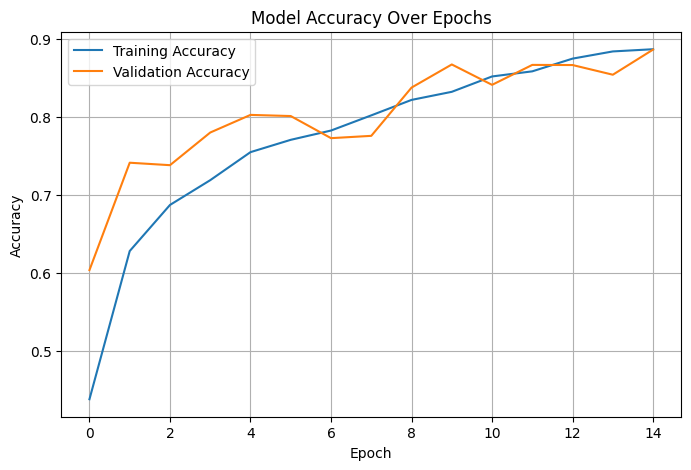

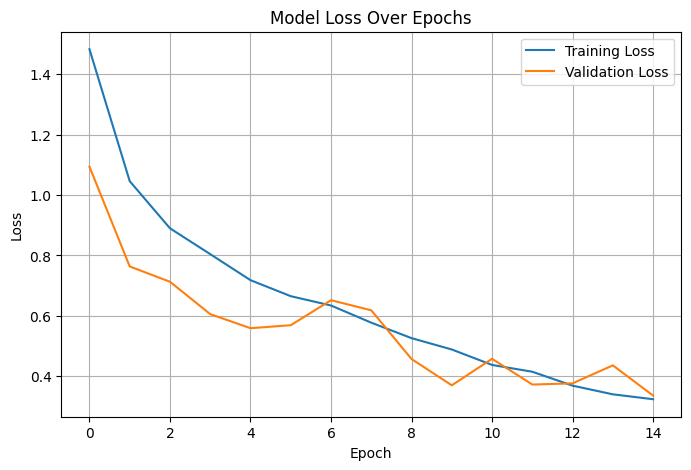

In [6]:
import matplotlib.pyplot as plt

# Accuracy graph
plt.figure(figsize=(8,5))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Model Accuracy Over Epochs')
plt.legend()
plt.grid()
plt.show()


# Loss graph
plt.figure(figsize=(8,5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Model Loss Over Epochs')
plt.legend()
plt.grid()
plt.show()

# Testing Model Prediction

In [7]:
import numpy as np

# Get predictions
predictions = model.predict(val_data)

# Convert probabilities to class numbers
y_pred = np.argmax(predictions, axis=1)

# True labels
y_true = val_data.classes

print("Predictions completed")

169/169 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step
Predictions completed


# Classification Report


In [8]:
from sklearn.metrics import classification_report

class_names = list(train_data.class_indices.keys())

print(classification_report(
    y_true,
    y_pred,
    target_names=class_names
))

                      precision    recall  f1-score   support

          AnnualCrop       0.11      0.10      0.10       600
              Forest       0.12      0.11      0.11       600
HerbaceousVegetation       0.11      0.11      0.11       600
             Highway       0.09      0.08      0.08       500
          Industrial       0.10      0.11      0.10       500
             Pasture       0.08      0.09      0.08       400
       PermanentCrop       0.09      0.09      0.09       500
         Residential       0.11      0.11      0.11       600
               River       0.09      0.09      0.09       500
             SeaLake       0.08      0.08      0.08       600

            accuracy                           0.10      5400
           macro avg       0.10      0.10      0.10      5400
        weighted avg       0.10      0.10      0.10      5400



# Confusion Matrix

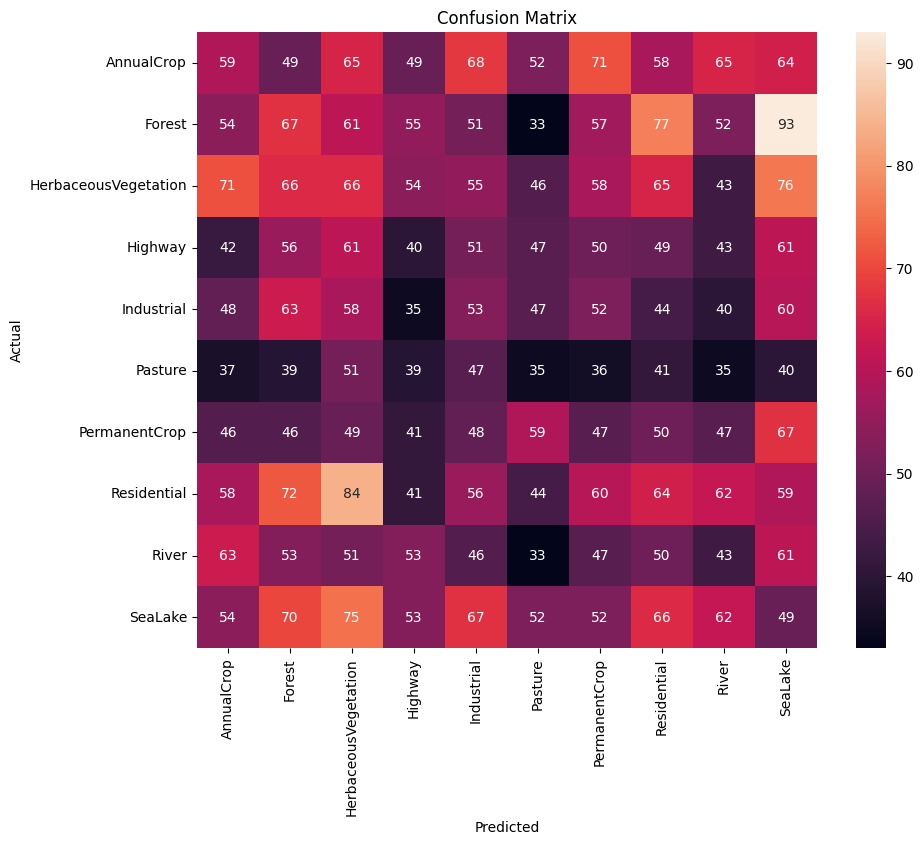

In [9]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10,8))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

# Saving Model

In [10]:
model.save("EuroSAT_CNN_Model.h5")

print("Model saved successfully!")

Model saved successfully!


# Testing the Model On Random Satellite Image

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 871ms/step


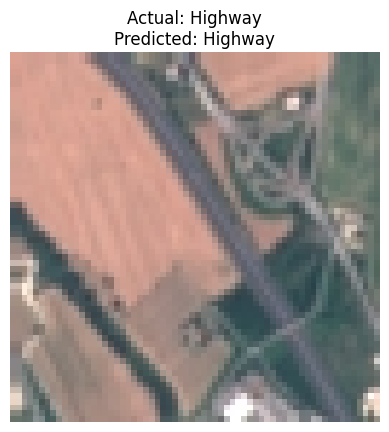

In [11]:
import random
from tensorflow.keras.preprocessing import image
import matplotlib.pyplot as plt
import os
import numpy as np

# Pick random class and image
random_class = random.choice(os.listdir(data_dir))
random_image = random.choice(os.listdir(os.path.join(data_dir, random_class)))

img_path = os.path.join(data_dir, random_class, random_image)

# Load image
img = image.load_img(img_path, target_size=(64,64))
img_array = image.img_to_array(img)/255.0
img_array = np.expand_dims(img_array, axis=0)

# Predict
prediction = model.predict(img_array)
predicted_class = list(train_data.class_indices.keys())[np.argmax(prediction)]

# Display
plt.imshow(img)
plt.axis("off")
plt.title(f"Actual: {random_class}\nPredicted: {predicted_class}")
plt.show()

# Final Results Summary

In [12]:
test_loss, test_accuracy = model.evaluate(val_data)

print("Final Validation Accuracy:", test_accuracy)
print("Final Validation Loss:", test_loss)

169/169 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - accuracy: 0.8867 - loss: 0.3361
Final Validation Accuracy: 0.8866666555404663
Final Validation Loss: 0.3360559642314911


# Final Accuracy

In [13]:
test_loss, test_accuracy = model.evaluate(val_data)

print(f"Validation Accuracy: {test_accuracy*100:.2f}%")
print(f"Validation Loss: {test_loss:.4f}")

169/169 ━━━━━━━━━━━━━━━━━━━━ 4s 22ms/step - accuracy: 0.8867 - loss: 0.3361
Validation Accuracy: 88.67%
Validation Loss: 0.3361


# Creating a folder to save my figures

In [14]:
import os

os.makedirs("paper_figures", exist_ok=True)

# Saving My Accuracy Graph

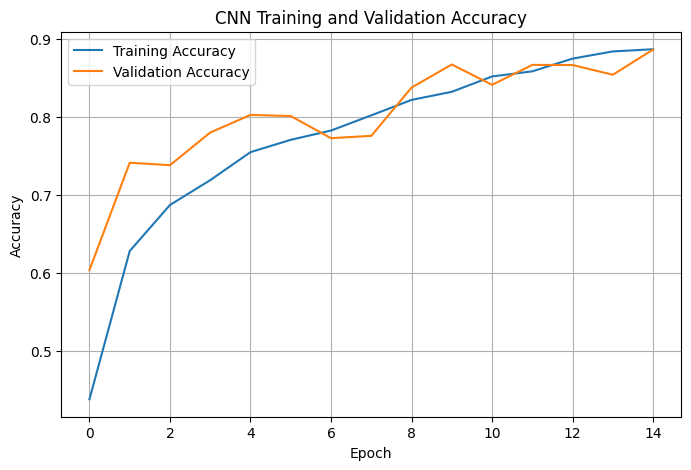

In [15]:
plt.figure(figsize=(8,5))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('CNN Training and Validation Accuracy')
plt.legend()
plt.grid()

plt.savefig("paper_figures/accuracy_curve.png", dpi=300, bbox_inches="tight")
plt.show()

# Saving My Loss Graph

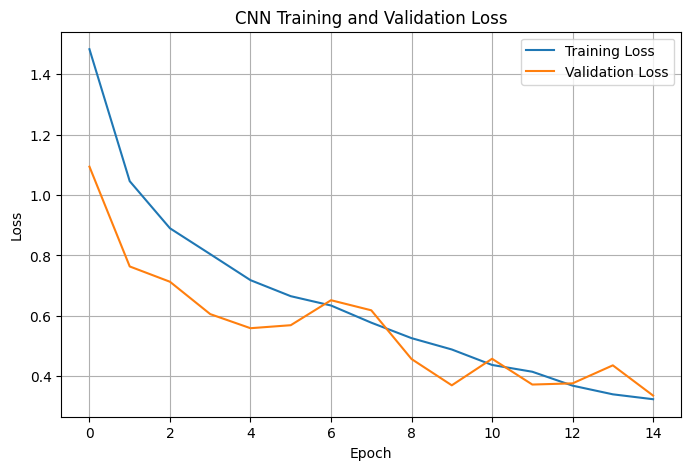

In [16]:
plt.figure(figsize=(8,5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('CNN Training and Validation Loss')
plt.legend()
plt.grid()

plt.savefig("paper_figures/loss_curve.png", dpi=300, bbox_inches="tight")
plt.show()

Saving My Confusion Matrix

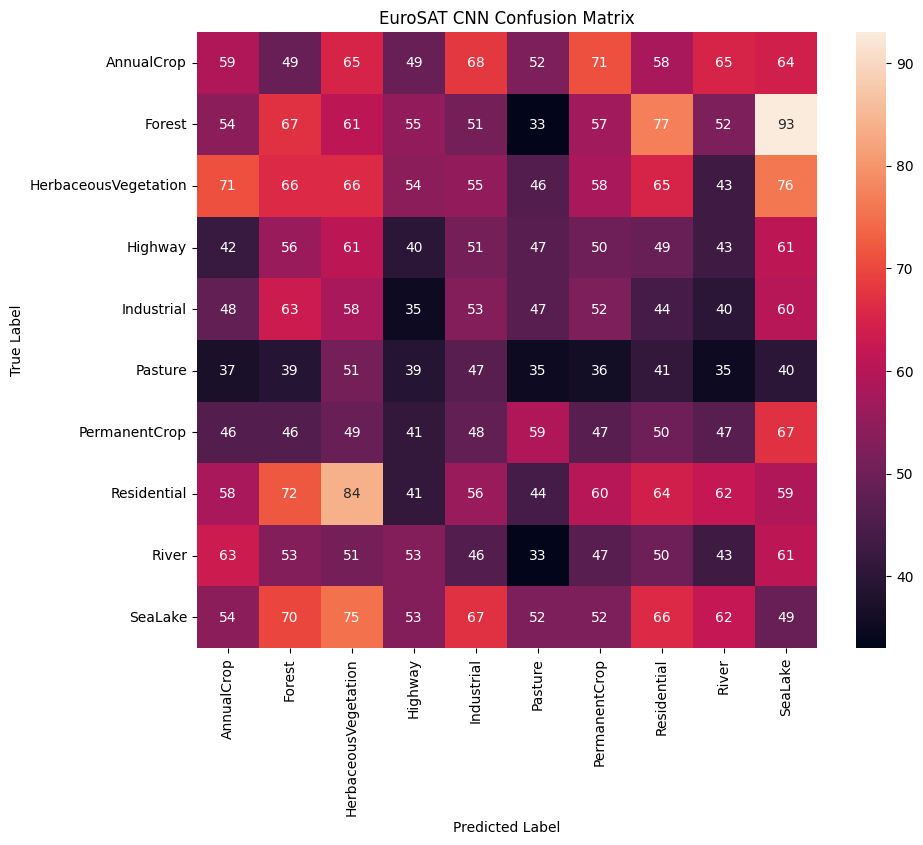

In [17]:
plt.figure(figsize=(10,8))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("EuroSAT CNN Confusion Matrix")

plt.savefig("paper_figures/confusion_matrix.png", dpi=300, bbox_inches="tight")
plt.show()

## Results

The convolutional neural network was trained for 15 epochs using the EuroSAT satellite image dataset containing 10 land-cover categories. The model performance was evaluated using validation accuracy, loss curves, classification metrics, and a confusion matrix.

The CNN achieved a validation accuracy of 88.67 % with a validation loss of 33.61% . The accuracy curve shows that the model improved consistently during training, demonstrating that the network successfully learned meaningful features from satellite images.

The confusion matrix demonstrates that the model was able to correctly classify multiple land-cover types, including categories with visually distinct characteristics such as Forest, SeaLake, and Industrial areas. Some confusion occurred between visually similar classes such as AnnualCrop and PermanentCrop, which contain similar vegetation patterns.

Overall, the results demonstrate that convolutional neural networks can effectively classify satellite imagery and identify different land-cover categories automatically.

## Discussion

The results indicate that deep learning methods can be successfully applied to satellite image classification. The CNN was able to extract important spatial features from Sentinel-2 satellite images without requiring manual feature engineering.

The strongest predictions occurred in classes with distinct visual patterns, such as forests, water bodies, and industrial regions. However, some classification errors occurred between categories with similar appearances, particularly agricultural land classes. These errors are likely caused by similarities in texture, color, and vegetation patterns between different land-cover types.

Increasing the amount of training data, applying data augmentation techniques, or using more advanced architectures such as transfer learning with pretrained models could potentially improve classification performance.

## Limitations

Although the CNN achieved effective classification performance, several limitations remain. The model was trained only on the EuroSAT dataset, meaning its performance may decrease when applied to satellite imagery from different geographic regions or environmental conditions.

Additionally, the model uses RGB satellite images and does not utilize additional spectral bands available from Sentinel-2 imagery. Including multispectral information could provide more detailed information about land-cover characteristics.

Future improvements could include using transfer learning models such as ResNet or EfficientNet, adding image augmentation, and testing the model on independent satellite datasets.

## Conclusion

This study investigated whether deep learning techniques could automatically classify satellite images into different land-cover categories. A convolutional neural network was developed and trained using the EuroSAT dataset containing 10 land-cover classes.

The model demonstrated that CNNs can accurately recognize patterns within satellite imagery and perform automated land-cover classification. These results highlight the potential of artificial intelligence for applications such as environmental monitoring, urban planning, and deforestation analysis.

Future research could improve performance by implementing advanced deep learning architectures and incorporating additional satellite data sources.